### BERTopic: 文本 → embedding → UMAP → HDBSCAN → topic extraction → 可视化

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

import umap
import hdbscan
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

# ==============================
# 0) 建议先关掉 tokenizers 并行警告
# ==============================
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ==============================
# 1) 可调参数：目标是“主题岛屿”聚集
# ==============================
# 文本权重：现在改成“主题聚类”，不要再用材料/合金token强行拉簇
ALLOY_BOOST_N = 0
MATERIAL_BOOST_N = 0

# 聚类用 UMAP（高维）——关键点：不要用2D聚类
UMAP_CLUSTER_N_COMPONENTS = 10     # 5~15 都可，越高越保结构
UMAP_CLUSTER_NEIGHBORS = 35        # 越大越“整体”，簇更稳定（不碎）
UMAP_CLUSTER_MIN_DIST = 0.0

# 可视化用 UMAP（2D）
UMAP_VIZ_NEIGHBORS = 20            # 10~30 常用
UMAP_VIZ_MIN_DIST = 0.05           # 越小越紧
UMAP_VIZ_SPREAD = 1.0

# HDBSCAN：控制“簇大小/紧密度”
MIN_CLUSTER_SIZE = 35              # 越大 -> 簇更少更大更集中
MIN_SAMPLES = 10                   # 越大 -> 噪声更多，但簇更“硬”
# BERTopic：主题最小规模（和 HDBSCAN 相互配合）
MIN_TOPIC_SIZE = 35

TOPK_LABEL = 20                    # 右侧最多显示多少簇
RANDOM_STATE = 42

# ==============================
# 2) 读取数据 + 拼文档
# ==============================
input_path = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/MetaData/Merged.xlsx"
sheet_name = "Sheet1"
df = pd.read_excel(input_path, sheet_name=sheet_name)

title = df.get("Title", "").fillna("").astype(str)
abstract = df.get("Abstract", "").fillna("").astype(str)

ak = df.get("Author Keywords", "").fillna("").astype(str)
kp = df.get("Keywords Plus", "").fillna("").astype(str)

# 统一分隔符，避免断裂
ak = ak.str.replace(";", " ", regex=False)
kp = kp.str.replace(";", " ", regex=False)

keywords = (ak + " " + kp).str.strip()

# 轻量清洗（别太重，否则主题词会被洗掉）
def clean_text(s: str) -> str:
    s = s.replace("\n", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

docs = (title + " " + keywords + " " + abstract).apply(clean_text).tolist()

# ==============================
# 3) 句向量 embedding（先算好，后面两套UMAP复用）
# ==============================
embedding_model = SentenceTransformer("all-mpnet-base-v2")
embeddings = embedding_model.encode(
    docs, show_progress_bar=True, batch_size=64, normalize_embeddings=True
)

# ==============================
# 4) 两套 UMAP：聚类(高维) + 可视化(2D)
# ==============================
umap_cluster = umap.UMAP(
    n_neighbors=UMAP_CLUSTER_NEIGHBORS,
    n_components=UMAP_CLUSTER_N_COMPONENTS,
    min_dist=UMAP_CLUSTER_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_STATE
)

umap_viz = umap.UMAP(
    n_neighbors=UMAP_VIZ_NEIGHBORS,
    n_components=2,
    min_dist=UMAP_VIZ_MIN_DIST,
    spread=UMAP_VIZ_SPREAD,
    metric="cosine",
    random_state=RANDOM_STATE
)

# HDBSCAN 作为聚类器（让簇更像“岛”）
hdb = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# ==============================
# 5) BERTopic（主题更集中：KeyBERTInspired 让主题词更干净）
# ==============================
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3
)

topic_model = BERTopic(
    embedding_model=embedding_model,   # ← 加这一行
    umap_model=umap_cluster,
    hdbscan_model=hdb,
    vectorizer_model=vectorizer_model,
    representation_model=KeyBERTInspired(),
    min_topic_size=MIN_TOPIC_SIZE,
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
df["topic"] = topics

# 关键后处理：把“离群点”尽量吸回主题（让同色更聚）
df["topic"] = topic_model.reduce_outliers(docs, df["topic"].values, strategy="c-tf-idf")

# 可选：进一步把主题数量自动收敛（让颜色更少更大）
# topic_model.reduce_topics(docs, nr_topics="auto")

# ==============================
# 6) 2D坐标：用独立 UMAP(2D) 投影 embeddings（只负责画图）
# ==============================
umap_2d = umap_viz.fit_transform(embeddings)
df["umap_x"] = umap_2d[:, 0]
df["umap_y"] = umap_2d[:, 1]

# ==============================
# 7) 右侧“簇编号 <-> 名称” + 图中只画编号圆点（不画大段文字）
# ==============================
# 主题大小
topic_sizes = (
    pd.Series(df["topic"])
    .value_counts()
)

# 取 TopK（排除 -1）
top_topics = [t for t in topic_sizes.index.tolist() if t != -1][:TOPK_LABEL]
rank_map = {t: i + 1 for i, t in enumerate(top_topics)}

def topic_short_name(tid: int) -> str:
    # 用主题词命名（避免 unknown）
    words = topic_model.get_topic(tid) or []
    top_words = [w for w, _ in words[:4]]
    if top_words:
        # 你要“单词/双词”风格：这里最多取2个也行
        return " / ".join(top_words[:3])
    return f"Topic {tid}"

name_map = {t: topic_short_name(t) for t in top_topics}

# 每个topic在2D上的“中心”
centers = (
    df[df["topic"].isin(top_topics)]
    .groupby("topic")[["umap_x", "umap_y"]]
    .median()
    .reset_index()
)
centers["rank_no"] = centers["topic"].map(rank_map)
centers["name"] = centers["topic"].map(name_map)
centers["count"] = centers["topic"].map(topic_sizes.to_dict())

# ==============================
# 8) 画图：像参考图一样“主题岛屿”
#    - 点按 topic 着色
#    - 图内只标 1..K 编号圆点
#    - 右侧列表显示编号对应的主题名
# ==============================
plt.figure(figsize=(15, 9))
plt.subplots_adjust(right=0.73)

sc = plt.scatter(
    df["umap_x"], df["umap_y"],
    c=df["topic"],
    cmap="tab20",
    s=10,
    alpha=0.85
)

plt.title("Topic-Clustered UMAP (BERTopic + HDBSCAN)", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

cbar = plt.colorbar(sc, fraction=0.03, pad=0.02)
cbar.set_label("Topic ID")

# 图中编号（对应右侧）
for _, r in centers.sort_values("rank_no").iterrows():
    x, y, k = r["umap_x"], r["umap_y"], int(r["rank_no"])
    plt.scatter([x], [y], s=260, c="white", edgecolors="black", linewidths=1.0, zorder=5)
    plt.text(x, y, str(k), ha="center", va="center",
             fontsize=10, weight="bold", color="black", zorder=6)

# 右侧列表
plt.gcf().text(0.745, 0.96, "Top clusters (numbered on map)", fontsize=11, weight="bold")
x0, y0, line_h = 0.745, 0.92, 0.028 

for i, r in enumerate(centers.sort_values("rank_no").itertuples()):
    plt.gcf().text(
        x0, y0 - i * line_h,
        f"{r.rank_no:>2}  ({int(r.count)})  {r.name}",
        fontsize=9
    )

plt.show()

# ==============================
# 9) 输出
# ==============================
out_path = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/Copper_Alloy_BERTopic_Result.xlsx"
df.to_excel(out_path, index=False)
print(f"\nDone. Saved: {out_path}")

### 莫兰迪色系 UMAP 2-Dims 图

In [1]:
import pandas as pd
import re

# =========================
# 配置区（改这里就行）
# =========================
excel_path = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/BERTopic/BERTopic_Result2.xlsx"
sheet_name = "Sheet1"          # 或 0
filter_col = "Abstract"    # 需要检索关键词的列名

keywords = ["precipitation", "refinement", "mechancial properties","strength"]  # 关键词列表
mode = "OR"  # "OR"：包含任意一个关键词；"AND"：必须同时包含所有关键词

out_path = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/BERTopic/filtered.xlsx"
# =========================

df = pd.read_excel(excel_path, sheet_name=sheet_name, dtype=object)

# 确保列存在
if filter_col not in df.columns:
    raise ValueError(f"Column '{filter_col}' not found. Available: {list(df.columns)}")

s = df[filter_col].astype(str)

if mode.upper() == "OR":
    pattern = "|".join(re.escape(k) for k in keywords)
    mask = s.str.contains(pattern, case=False, na=False, regex=True)
elif mode.upper() == "AND":
    mask = pd.Series(True, index=df.index)
    for k in keywords:
        mask &= s.str.contains(re.escape(k), case=False, na=False, regex=True)
else:
    raise ValueError("mode must be 'OR' or 'AND'")

filtered = df.loc[mask].copy()

# 导出
filtered.to_excel(out_path, index=False)
print(f"Saved {len(filtered)} rows to: {out_path}")

Saved 24669 rows to: /Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/BERTopic/filtered.xlsx


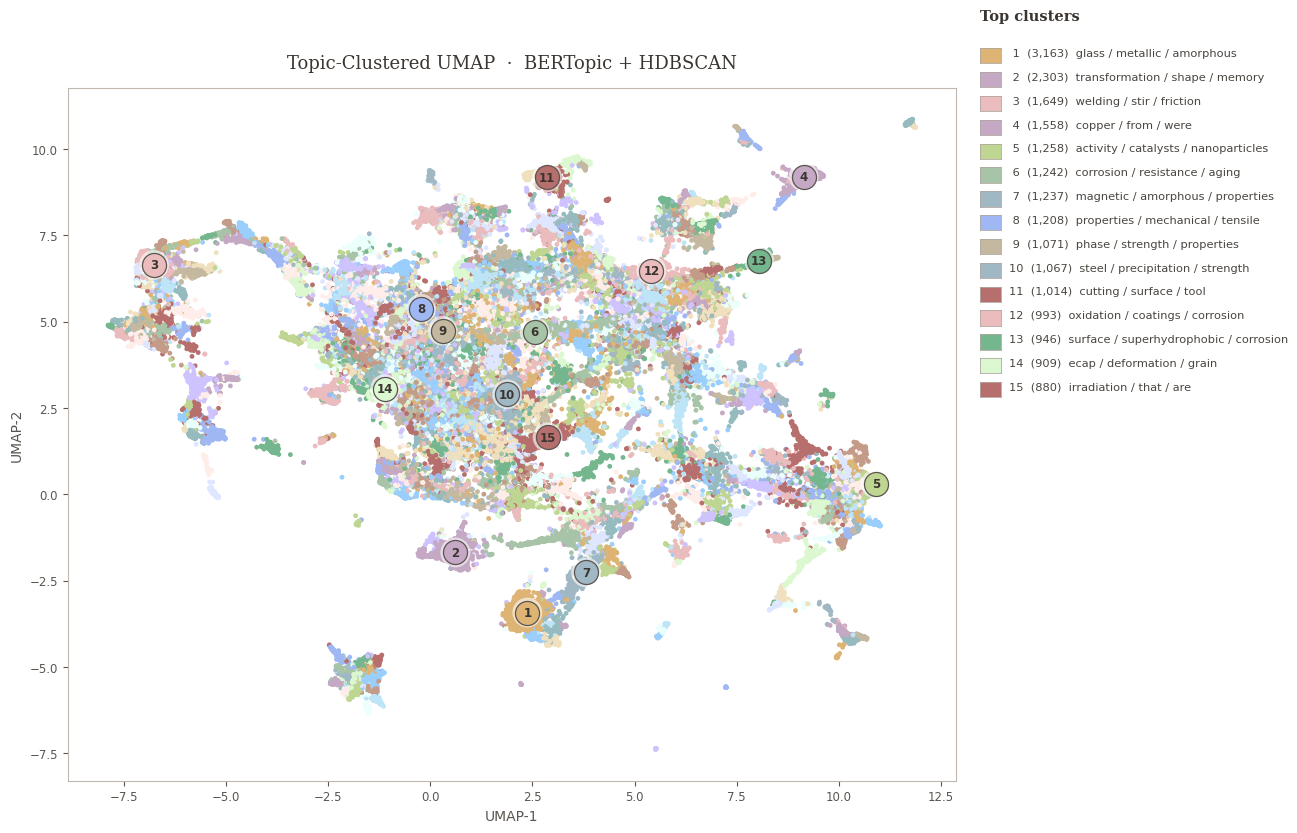

已保存: /Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/BERTopic/BERTopic-1.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==============================
# 1) 直接读取已有结果
# ==============================
input_path = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/BERTopic/BERTopic_Result.xlsx"
df = pd.read_excel(input_path)

# 确认必要列存在
assert "topic"  in df.columns, "缺少 topic 列"
assert "umap_x" in df.columns, "缺少 umap_x 列"
assert "umap_y" in df.columns, "缺少 umap_y 列"

# ==============================
# 2) 主题排序 & 标签
# ==============================
TOPK_LABEL = 15

topic_sizes = pd.Series(df["topic"]).value_counts()
top_topics  = [t for t in topic_sizes.index.tolist() if t != -1][:TOPK_LABEL]
rank_map    = {t: i + 1 for i, t in enumerate(top_topics)}

# ── 没有 topic_model，用词频手动构造标签 ──
# 从 Author Keywords + Keywords Plus 提取每个 topic 的高频词
ak = df.get("Author Keywords", pd.Series([""] * len(df))).fillna("").astype(str)
kp = df.get("Keywords Plus",   pd.Series([""] * len(df))).fillna("").astype(str)
df["_kw"] = (ak + " " + kp).str.replace(";", " ", regex=False).str.lower()

from collections import Counter
import re

STOPWORDS = {
    "alloy", "alloys", "and", "of", "in", "the", "a", "an",
    "with", "for", "on", "by", "to", "effect", "effects",
    "study", "based", "using", "via"
}

def top_words_for_topic(tid, n=3):
    texts = df.loc[df["topic"] == tid, "_kw"]
    words = re.findall(r"[a-z]{3,}", " ".join(texts))
    words = [w for w in words if w not in STOPWORDS]
    common = Counter(words).most_common(n)
    return " / ".join(w for w, _ in common) if common else f"Topic {tid}"

name_map = {t: top_words_for_topic(t) for t in top_topics}

centers = (
    df[df["topic"].isin(top_topics)]
    .groupby("topic")[["umap_x", "umap_y"]]
    .median()
    .reset_index()
)
centers["rank_no"] = centers["topic"].map(rank_map)
centers["name"]    = centers["topic"].map(name_map)
centers["count"]   = centers["topic"].map(topic_sizes.to_dict())

# ==============================
# 过滤：去掉远离各自 topic 中心的离群点（推荐）
# ==============================
# 只对非噪声 topic 做（-1 不处理或直接删掉也行）
non_noise = df["topic"] != -1

# 计算每个 topic 的中心（你前面已经算过 topic_centers，这里确保是 DataFrame）
topic_centers_xy = (
    df[non_noise]
    .groupby("topic")[["umap_x", "umap_y"]]
    .median()
)

# 把每行对应topic的中心坐标映射回来
df["_cx"] = df["topic"].map(topic_centers_xy["umap_x"])
df["_cy"] = df["topic"].map(topic_centers_xy["umap_y"])

# 距离：到自己topic中心
df["_dist_to_topic"] = np.sqrt((df["umap_x"] - df["_cx"])**2 + (df["umap_y"] - df["_cy"])**2)

# ---- 方式1：分位数阈值（每个topic删最远的 q%）----
KEEP_Q = 0.95  # 保留95%，删最远5%（可改 0.90 / 0.97）
thr = (
    df[non_noise]
    .groupby("topic")["_dist_to_topic"]
    .quantile(KEEP_Q)
)
df["_thr"] = df["topic"].map(thr)

keep_mask = (df["topic"] != -1) & (df["_dist_to_topic"] <= df["_thr"])
df = df.loc[keep_mask].copy()

# 清理临时列（可选）
df.drop(columns=["_cx", "_cy", "_thr"], inplace=True, errors="ignore")


# ==============================
# 3) 古典诗意配色
# ==============================
SHIYII_PALETTE = [
    "#CEC3FF",  # 微兰
    "#74B68D",  # 碧落
    "#FFEDE9",  # 蔽月
    "#DBF8D0",  # 清欢
    "#EABCBD",  # 惊鸿
    "#BFD693",  # 寻者
    "#DEE7FF",  # 轻云
    "#DEB475",  # 立黄昏
    "#B76F6D",  # 烟霞
    "#9ACEFC",  # 疏雨
    "#C39B88",  # 灯花
    "#EBFFFD",  # 清明
    "#F1E0BE",  # 梨花雪
    "#BEE4F8",  # 清影
    "#96BBBE",  # 玲珑
    "#9FB8F3",  # 无尘
    "#C4A8C4",  # 淡紫
    "#A8C4A8",  # 竹青
    "#C4B8A0",  # 旧纸
    "#A0B8C4",  # 霁蓝
]

non_noise_topics = [t for t in sorted(df["topic"].unique()) if t != -1]

topic_centers = (
    df[df["topic"].isin(non_noise_topics)]
    .groupby("topic")[["umap_x", "umap_y"]]
    .median()
)
cx = topic_centers["umap_x"].mean()
cy = topic_centers["umap_y"].mean()
topic_centers["angle"] = np.arctan2(
    topic_centers["umap_y"] - cy,
    topic_centers["umap_x"] - cx
)
topic_centers_sorted = topic_centers.sort_values("angle").reset_index()

topic_color_map = {}
for i, row in topic_centers_sorted.iterrows():
    tid = row["topic"]
    topic_color_map[tid] = mcolors.to_rgba(
        SHIYII_PALETTE[i % len(SHIYII_PALETTE)]
    )[:3]

topic_color_map[-1] = mcolors.to_rgba("#C8C0B8")[:3]  # 噪声：暖灰

point_colors = np.array([topic_color_map[t] for t in df["topic"]])

# ==============================
# 4) 画图（透明背景）
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_alpha(0)
ax.set_facecolor("none")
plt.subplots_adjust(right=0.68)

noise_mask  = df["topic"] == -1
signal_mask = ~noise_mask

# 噪声点
ax.scatter(
    df.loc[noise_mask, "umap_x"], df.loc[noise_mask, "umap_y"],
    c=[topic_color_map[-1]], s=5, alpha=0.30, linewidths=0, zorder=1
)

# 主题点（实心，无 alpha）
ax.scatter(
    df.loc[signal_mask, "umap_x"], df.loc[signal_mask, "umap_y"],
    c=point_colors[signal_mask.values],
    s=12, linewidths=0, zorder=2
)

ax.set_title("Topic-Clustered UMAP  ·  BERTopic + HDBSCAN",
             fontsize=13, color="#3A3530", pad=14, fontfamily="serif")
ax.set_xlabel("UMAP-1", color="#5A5550", fontsize=10)
ax.set_ylabel("UMAP-2", color="#5A5550", fontsize=10)
ax.tick_params(colors="#5A5550", labelsize=8.5)
for spine in ax.spines.values():
    spine.set_edgecolor("#C0B8B0")

# 编号圆点
for _, r in centers.sort_values("rank_no").iterrows():
    x, y, k = r["umap_x"], r["umap_y"], int(r["rank_no"])
    bg = topic_color_map.get(r["topic"], [0.85, 0.83, 0.80])
    ax.scatter([x], [y], s=460, c=["white"], edgecolors="none",
               alpha=0.6, zorder=4)
    ax.scatter([x], [y], s=300, c=[bg], edgecolors="#5A5550",
               linewidths=0.9, zorder=5)
    ax.text(x, y, str(k), ha="center", va="center",
            fontsize=8.5, weight="bold", color="#3A3530", zorder=6)

# 右侧图例
fig.text(0.695, 0.955, "Top clusters", fontsize=10.5,
         weight="bold", color="#3A3530", fontfamily="serif")

x0, y0, line_h = 0.695, 0.915, 0.0265

for i, r in enumerate(centers.sort_values("rank_no").itertuples()):
    rgb = topic_color_map.get(r.topic, [0.8, 0.78, 0.76])

    rect_ax = fig.add_axes([x0, y0 - i * line_h - 0.008, 0.013, 0.017])
    rect_ax.set_facecolor(rgb)
    rect_ax.set_xticks([])
    rect_ax.set_yticks([])
    for sp in rect_ax.spines.values():
        sp.set_edgecolor("#B0A8A0")
        sp.set_linewidth(0.6)

    fig.text(
        x0 + 0.018, y0 - i * line_h,
        f"{r.rank_no:>2}  ({int(r.count):,})  {r.name}",
        fontsize=8.2, color="#4A4540"
    )

# ==============================
# 5) 保存
# ==============================
png_path = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/BERTopic/BERTopic-1.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"已保存: {png_path}")

### 主题分析 + 局部主题放大

In [3]:
print("原始数据量:", len(pd.read_excel(input_path)))
print("过滤后数据量:", len(df))
print("主题数量（不含噪声 -1）:", len(non_noise_topics))
print("Top 15 topics:", top_topics)

print("\nTop topic sizes:")
print(topic_sizes.head(20))

print("\nTop 15 topic labels:")
print(
    centers.sort_values("rank_no")[["rank_no", "topic", "count", "name"]]
    .to_string(index=False)
)

print("\n过滤后各 topic 数量:")
print(df["topic"].value_counts().head(20))

print("\nUMAP 坐标范围:")
print("umap_x:", df["umap_x"].min(), "to", df["umap_x"].max())
print("umap_y:", df["umap_y"].min(), "to", df["umap_y"].max())

原始数据量: 122982
过滤后数据量: 116643
主题数量（不含噪声 -1）: 457
Top 15 topics: [0, 1, 4, 2, 5, 9, 3, 24, 32, 7, 6, 10, 8, 17, 11]

Top topic sizes:
topic
0     3163
1     2303
4     1649
2     1558
5     1258
9     1242
3     1237
24    1208
32    1071
7     1067
6     1014
10     993
8      946
17     909
11     880
26     879
21     861
37     828
23     815
46     813
Name: count, dtype: int64

Top 15 topic labels:
 rank_no  topic  count                                   name
       1      0   3163           glass / metallic / amorphous
       2      1   2303        transformation / shape / memory
       3      4   1649              welding / stir / friction
       4      2   1558                   copper / from / were
       5      5   1258   activity / catalysts / nanoparticles
       6      9   1242         corrosion / resistance / aging
       7      3   1237      magnetic / amorphous / properties
       8     24   1208      properties / mechanical / tensile
       9     32   1071          phas

In [5]:
topic_summary = centers.sort_values("rank_no")[["rank_no", "topic", "count", "name"]]
topic_summary.to_excel("/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/BERTopic/topic_summary.xlsx", index=False)
print("已导出 topic summary")

已导出 topic summary


In [6]:
# ==============================
# 6) 输出论文可用统计信息
# ==============================

# 重新读取原始数据，避免过滤后覆盖
df_raw = pd.read_excel(input_path)

total_docs_raw = len(df_raw)
noise_count_raw = (df_raw["topic"] == -1).sum()
non_noise_count_raw = (df_raw["topic"] != -1).sum()
n_topics_raw = df_raw.loc[df_raw["topic"] != -1, "topic"].nunique()

total_docs_after_filter = len(df)
n_topics_after_filter = df.loc[df["topic"] != -1, "topic"].nunique()

print("\n===== BERTopic–UMAP Summary =====")
print(f"原始文献总数: {total_docs_raw:,}")
print(f"非噪声文献数: {non_noise_count_raw:,}")
print(f"噪声文献数: {noise_count_raw:,}")
print(f"噪声比例: {noise_count_raw / total_docs_raw:.2%}")
print(f"识别出的非噪声主题数: {n_topics_raw}")
print(f"离群点过滤后保留文献数: {total_docs_after_filter:,}")
print(f"离群点过滤后保留比例: {total_docs_after_filter / total_docs_raw:.2%}")
print(f"过滤后主题数: {n_topics_after_filter}")

print("\n===== Top 15 Topic Clusters =====")
topic_summary = centers.sort_values("rank_no")[["rank_no", "topic", "count", "name"]]
topic_summary["percentage_raw"] = topic_summary["count"] / total_docs_raw * 100
print(topic_summary.to_string(index=False))

print("\n===== UMAP Coordinate Range =====")
print(f"UMAP-1: {df['umap_x'].min():.3f} to {df['umap_x'].max():.3f}")
print(f"UMAP-2: {df['umap_y'].min():.3f} to {df['umap_y'].max():.3f}")

# 导出表格，方便写论文
summary_path = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/BERTopic/BERTopic_topic_summary.xlsx"
topic_summary.to_excel(summary_path, index=False)
print(f"\n已导出 topic summary: {summary_path}")


===== BERTopic–UMAP Summary =====
原始文献总数: 122,982
非噪声文献数: 122,982
噪声文献数: 0
噪声比例: 0.00%
识别出的非噪声主题数: 457
离群点过滤后保留文献数: 116,643
离群点过滤后保留比例: 94.85%
过滤后主题数: 457

===== Top 15 Topic Clusters =====
 rank_no  topic  count                                   name  percentage_raw
       1      0   3163           glass / metallic / amorphous        2.571921
       2      1   2303        transformation / shape / memory        1.872632
       3      4   1649              welding / stir / friction        1.340847
       4      2   1558                   copper / from / were        1.266852
       5      5   1258   activity / catalysts / nanoparticles        1.022914
       6      9   1242         corrosion / resistance / aging        1.009904
       7      3   1237      magnetic / amorphous / properties        1.005838
       8     24   1208      properties / mechanical / tensile        0.982258
       9     32   1071          phase / strength / properties        0.870859
      10      7   1067       

In [7]:
print("\n===== BERTopic Pipeline Settings =====")
print("Input text fields: Title + Author Keywords + Keywords Plus + Abstract")
print("Embedding model: all-mpnet-base-v2")
print("Embedding normalization: True")
print(f"UMAP for clustering: n_components={UMAP_CLUSTER_N_COMPONENTS}, "
      f"n_neighbors={UMAP_CLUSTER_NEIGHBORS}, min_dist={UMAP_CLUSTER_MIN_DIST}, metric=cosine")
print(f"HDBSCAN: min_cluster_size={MIN_CLUSTER_SIZE}, min_samples={MIN_SAMPLES}, "
      "cluster_selection_method=eom")
print(f"UMAP for visualization: n_components=2, n_neighbors={UMAP_VIZ_NEIGHBORS}, "
      f"min_dist={UMAP_VIZ_MIN_DIST}, spread={UMAP_VIZ_SPREAD}, metric=cosine")
print("Topic representation: KeyBERTInspired")
print("Outlier reduction strategy: c-tf-idf")

print("\n===== Dataset and Topic Summary =====")
print(f"Total documents: {len(df):,}")
print(f"Number of topics including noise: {df['topic'].nunique()}")
print(f"Number of topics excluding noise: {df.loc[df['topic'] != -1, 'topic'].nunique()}")
print(f"Noise documents (-1): {(df['topic'] == -1).sum():,}")
print(f"Noise ratio: {(df['topic'] == -1).mean():.2%}")

topic_summary = centers.sort_values("rank_no")[["rank_no", "topic", "count", "name"]].copy()
topic_summary["percentage"] = topic_summary["count"] / len(df) * 100

print("\n===== Top Topic Clusters =====")
print(topic_summary.to_string(index=False))

summary_path = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/Copper_Alloy_BERTopic_Topic_Summary.xlsx"
topic_summary.to_excel(summary_path, index=False)
print(f"\nSaved topic summary: {summary_path}")


===== BERTopic Pipeline Settings =====
Input text fields: Title + Author Keywords + Keywords Plus + Abstract
Embedding model: all-mpnet-base-v2
Embedding normalization: True


NameError: name 'UMAP_CLUSTER_N_COMPONENTS' is not defined